In [72]:
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field 

from typing_extensions import TypedDict, Literal
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
model_openai = ChatOpenAI(model="gpt-4o-mini")
model_groq = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0 )
model_google = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0)


model_openai, model_groq, model_google

(ChatOpenAI(output_version=None, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001819BA5CE50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001819BA5CF50>, root_client=<openai.OpenAI object at 0x000001819BA5CB50>, root_async_client=<openai.AsyncOpenAI object at 0x000001819BA5D050>, model_name='gpt-4o-mini', model_kwargs={},

In [74]:
model_groq.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.054759618, 'completion_tokens_details': None, 'prompt_time': 0.006470153, 'prompt_tokens_details': None, 'queue_time': 0.159799084, 'total_time': 0.061229771}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dce2b-5adc-7383-b5c9-d63d8afef406-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [75]:
class ResumeData(TypedDict):
    JD: str
    Resume: str
    score: int
    advantages: list[str]
    disadvantages: list[str]
    cover_letter: str
    feedback: dict


In [76]:
class ResumeAnalyzer(BaseModel):
    score: int = Field(..., ge=0, le=100)
    advantages: list[str] = Field(..., min_length=1)
    disadvantages: list[str] = Field(..., min_length=1)


resume_analyzer_model = model_openai.with_structured_output(ResumeAnalyzer)

In [77]:
# analyze_resume() prompt

prompt = """ 
You are an expert resume analyst and hiring specialist with years of experience evaluating candidates across various industries.

You will be provided with:
1. A **Job Description (JD)**
2. A **Candidate's Resume**

Your task is to thoroughly analyze both and return a structured evaluation.

---

### INSTRUCTIONS:

Carefully read the Job Description and Resume, then evaluate the following:

1. **Match Score (0-100)**
   - Calculate a numeric score representing how well the resume matches the job description.
   - Base it on: skills match, experience relevance, education, certifications, and keywords.

2. **Advantages**
   - List the strong points of the candidate that align well with the JD.
   - Be specific and reference actual content from the resume.

3. **Disadvantages**
   - List the gaps, missing skills, or mismatches between the resume and JD.
   - Be specific and constructive.

---

### INPUT:

**Job Description:**
{job_description}

**Resume:**
{resume}

---

### OUTPUT FORMAT (Strict JSON only, no extra text):

{{
  "score": <integer 0-100>,
  "advantages": [
    "<advantage 1>",
    "<advantage 2>",
    ...
  ],
  "disadvantages": [
    "<disadvantage 1>",
    "<disadvantage 2>",
    ...
  ]
}}


 """



In [78]:
def pdf_read(state: ResumeData) -> ResumeData:
    return state

def analyze_resume(state: ResumeData) -> ResumeData:
    # Analyze the rsume using the prompt and return the structured output.
    # For demonstration, I'm returning a dummy response.
    result = resume_analyzer_model.invoke(prompt.format(job_description=state["JD"], resume=state["Resume"]))
    return {'advantages': result.advantages, 'disadvantages': result.disadvantages, 'score': result.score}
    
    

def routing_condition(state: ResumeData) -> Literal["Cover Letter Generator" , "Feedback Generator"]:
    if state["score"] >= 75:
        return "Cover Letter Generator"
    else:
        return "Feedback Generator"
    
    
    
    

In [79]:
class CoverLetterOutput(BaseModel):
    subject: str
    cover_letter: str


model_google_cover_letter = model_google.with_structured_output(CoverLetterOutput)

cover_letter_prompt = """ 
You are a professional cover letter writer with expertise in crafting 
compelling, personalized cover letters that get candidates noticed.

You will be provided with:
1. A **Job Description (JD)**
2. A **Candidate's Resume**
3. A **Resume Analysis** (score, advantages, disadvantages)

Your task is to write a professional and tailored cover letter that:
- Highlights the candidate's strengths that match the JD
- Addresses gaps subtly and positively
- Feels human, confident, and genuine — NOT generic or robotic

---

### INSTRUCTIONS:

1. Open with a strong, attention-grabbing introduction
2. In the body, emphasize the advantages identified in the analysis
   that directly align with the job requirements
3. Subtly handle disadvantages by showing willingness to learn
   or transferable skills where applicable
4. Close with a confident call-to-action
5. Keep the tone professional yet personable
6. Length: 3-4 paragraphs, concise and impactful

---

### INPUT:

**Job Description:**
{job_description}

**Resume:**
{resume}

**Resume Analysis:**
- Match Score: {score}
- Advantages: {advantages}
- Disadvantages: {disadvantages}

---

### OUTPUT FORMAT (Strict JSON only, no extra text):

{{
  "subject": "<Email subject line for the cover letter>",
  "cover_letter": "<Full cover letter text with proper paragraphs>"
}}


 """

In [ ]:
from typing import List

class SectionFeedback(BaseModel):
    skills: str = Field(description="Specific suggestions to improve skills section")
    work_experience: str = Field(description="Specific suggestions to improve experience section")
    education_certifications: str = Field(description="Suggestions for education or certifications to add")
    projects: str = Field(description="Suggestions for projects section")
    formatting_ats: str = Field(description="ATS and formatting improvement tips")
    missing_keywords: List[str] = Field(description="List of important keywords missing from the resume")


class FeedbackOutput(BaseModel):
    score_explanation: str = Field(description="Why the candidate received this score")
    section_feedback: SectionFeedback = Field(description="Section wise feedback for the resume")
    priority_actions: List[str] = Field(description="Top 3 most impactful changes the candidate should make")
    encouragement: str = Field(description="Short motivating closing note")

feedback_generator_prompt = """
You are an expert career coach and resume consultant with deep knowledge 
of hiring processes, ATS systems, and recruiter expectations across industries.

You will be provided with:
1. A **Job Description (JD)**
2. A **Candidate's Resume**
3. A **Resume Analysis** (score, advantages, disadvantages)

Your task is to generate detailed, actionable feedback explaining 
why the candidate scored the way they did and exactly how they 
can improve their resume to better match the job description.

---

### INSTRUCTIONS:

1. **Score Explanation**
   - Clearly explain what factors led to the current score
   - Break down which areas pulled the score down the most
   - Be honest but constructive

2. **Section-Wise Improvement Suggestions**
   Analyze and suggest improvements for each of these resume sections 
   (only include sections relevant to the JD):
   - Skills
   - Work Experience
   - Education & Certifications
   - Projects
   - Resume Formatting & ATS Optimization
   - Keywords & Buzzwords missing from the resume

3. **Priority Actions**
   - List the TOP 3 most impactful changes the candidate should 
     make immediately to increase their match score

4. **Encouragement**
   - End with a short motivating note that keeps the tone 
     supportive and forward-looking

---

### INPUT:

**Job Description:**
{job_description}

**Resume:**
{resume}

**Resume Analysis:**
- Match Score: {score}
- Advantages: {advantages}
- Disadvantages: {disadvantages}

---

### OUTPUT FORMAT (Strict JSON only, no extra text):

{{
  "score_explanation": "<Why the candidate received this score>",
  "section_feedback": {{
    "skills": "<Specific suggestions to improve skills section>",
    "work_experience": "<Specific suggestions to improve experience section>",
    "education_certifications": "<Suggestions for education or certifications to add>",
    "projects": "<Suggestions for projects section>",
    "formatting_ats": "<ATS and formatting improvement tips>",
    "missing_keywords": [
      "<keyword 1>",
      "<keyword 2>",
      ...
    ]
  }},
  "priority_actions": [
    "<Most impactful action 1>",
    "<Most impactful action 2>",
    "<Most impactful action 3>"
  ],
  "encouragement": "<Short motivating closing note>"
}}

"""

feedback_model = model_groq.with_structured_output(FeedbackOutput)


In [81]:
def cover_letter_generator(state: ResumeData):
    result = model_google_cover_letter.invoke(cover_letter_prompt.format(job_description=state["JD"], resume=state["Resume"], score=state["score"], advantages=state["advantages"], disadvantages=state["disadvantages"]))
    return {"cover_letter": result.cover_letter, "subject": result.subject}

def feedback_generator(state: ResumeData):
    result = feedback_model.invoke(feedback_generator_prompt.format(job_description=state["JD"], resume=state["Resume"], score=state["score"], advantages=state["advantages"], disadvantages=state["disadvantages"]))
    return {"feedback": result}

In [82]:
graph = StateGraph(ResumeData)

graph.add_node('Reading PDF', pdf_read)
graph.add_node('Analyzing Resume', analyze_resume)
graph.add_node("Cover Letter Generator", cover_letter_generator)

graph.add_node("Feedback Generator", feedback_generator)


graph.add_edge(START, 'Reading PDF')
graph.add_edge('Reading PDF', 'Analyzing Resume')
graph.add_conditional_edges('Analyzing Resume', routing_condition)
graph.add_edge("Feedback Generator", END)
graph.add_edge("Cover Letter Generator", END)




workflow = graph.compile()

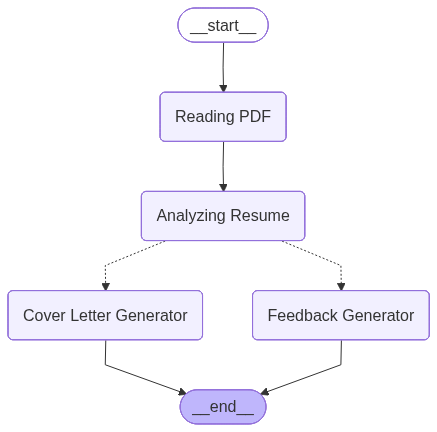

In [83]:
workflow

In [84]:
JD = """ Position: Senior Machine Learning Engineer
Company: TechCorp AI Solutions

About the Role:
We are looking for a Senior Machine Learning Engineer to join our 
AI team and lead the development of production-grade ML systems.

Requirements:
- 5+ years of experience in Machine Learning / Deep Learning
- Strong proficiency in Python, TensorFlow, PyTorch
- Experience with MLOps tools (MLflow, Kubeflow, Airflow)
- Hands-on experience with LLMs, Transformer architectures
- Experience deploying ML models on AWS/GCP/Azure
- Strong knowledge of Docker, Kubernetes
- Experience with distributed training (Horovod, Ray)
- Proficiency in SQL and NoSQL databases
- Strong understanding of NLP pipelines
- Experience leading a team of 3+ engineers
- Publications or contributions to ML research is a plus

Responsibilities:
- Design and deploy scalable ML pipelines
- Lead a team of junior ML engineers
- Collaborate with product and data teams
- Optimize model performance in production
- Research and implement state-of-the-art ML techniques """


resume = """ Name: Rohit Sharma
Email: rohit.sharma@email.com
Phone: +91-9876543210
Location: Delhi, India

OBJECTIVE:
Hardworking and enthusiastic fresher looking for opportunities 
to grow in the IT industry.

EDUCATION:
B.Com (Bachelor of Commerce)
Delhi University | 2020 - 2023
CGPA: 6.8 / 10

12th Standard - CBSE Board | 2020 | 65%
10th Standard - CBSE Board | 2018 | 72%

SKILLS:
- MS Excel (Intermediate)
- Tally ERP
- Basic Computer Knowledge
- MS Word, PowerPoint
- Good Communication Skills

WORK EXPERIENCE:
Accounts Intern | ABC Traders, Delhi | June 2023 - Dec 2023
- Maintained daily ledger entries
- Assisted in GST filing and invoice management
- Prepared monthly financial reports in Excel

PROJECTS:
- Created a monthly expense tracker in Excel
- Made a PowerPoint presentation on Digital Marketing 
  trends for college fest

CERTIFICATIONS:
- Tally ERP 9 Certification | 2023
- MS Office Certification | NIIT | 2022

HOBBIES:
Cricket, Listening to Music, Travelling

LANGUAGES:
English, Hindi """

In [85]:
result = workflow.invoke({"JD": JD, "Resume": resume})

In [87]:
result

{'JD': ' Position: Senior Machine Learning Engineer\nCompany: TechCorp AI Solutions\n\nAbout the Role:\nWe are looking for a Senior Machine Learning Engineer to join our \nAI team and lead the development of production-grade ML systems.\n\nRequirements:\n- 5+ years of experience in Machine Learning / Deep Learning\n- Strong proficiency in Python, TensorFlow, PyTorch\n- Experience with MLOps tools (MLflow, Kubeflow, Airflow)\n- Hands-on experience with LLMs, Transformer architectures\n- Experience deploying ML models on AWS/GCP/Azure\n- Strong knowledge of Docker, Kubernetes\n- Experience with distributed training (Horovod, Ray)\n- Proficiency in SQL and NoSQL databases\n- Strong understanding of NLP pipelines\n- Experience leading a team of 3+ engineers\n- Publications or contributions to ML research is a plus\n\nResponsibilities:\n- Design and deploy scalable ML pipelines\n- Lead a team of junior ML engineers\n- Collaborate with product and data teams\n- Optimize model performance in 